# Procesamiento de Lenguaje Natural
## Desafío 2 — Custom Embeddings con Gensim
### Artista elegido: **Blink-182**

---

El objetivo es entrenar nuestros propios **word embeddings** (vectores de palabras) usando las letras de canciones de **Blink-182**.


---
## Corpus

El dataset contiene un archivo `blink-182.txt` donde cada línea es una oración/verso de alguna canción. Así se ve por dentro:

```
all the small things true care truth brings
say it ain't so i will not go
hello there the angel from my nightmare
well i guess this is growing up
...
```

Cada línea = un **documento**

### Importar librerías



In [2]:
import pandas as pd
import os
import platform

# Gensim es la librería que vamos a usar para crear los embeddings
# Si no está instalada, la instalamos automáticamente
try:
    from gensim.models import Word2Vec
    print('Gensim ya está instalado')
except ImportError:
    !pip install gensim
    from gensim.models import Word2Vec
    print('Gensim instalado correctamente')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 83.8 MB/s eta 0:00:00
Gensim instalado correctamente


### Descarga del dataset

El dataset vive en el repositorio de la cátedra como un archivo `.zip`. Lo descargamos y descomprimimos. El código verifica primero si ya lo tenemos descargado para no repetir la descarga.

In [3]:
# Verificamos si ya tenemos la carpeta del dataset
# Si no existe, descargamos el zip y lo descomprimimos
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        # El comando depende del sistema operativo:
        # Windows usa curl, Linux/Mac usa wget
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print('El dataset ya se encuentra descargado')

--2026-05-16 00:18:13--  http://songs_dataset.zip/
Resolving songs_dataset.zip (songs_dataset.zip)... failed: Name or service not known.
wget: unable to resolve host address ‘songs_dataset.zip’
--2026-05-16 00:18:13--  https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip [following]
--2026-05-16 00:18:14--  https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (

### Artistas disponibles


In [4]:
# Cada archivo corresponde a un artista diferente.
artistas = sorted(os.listdir('./songs_dataset/'))
print(f'Total de artistas disponibles: {len(artistas)}')
print()
for a in artistas:
    print(' -', a)

Total de artistas disponibles: 49

 - Kanye_West.txt
 - Lil_Wayne.txt
 - adele.txt
 - al-green.txt
 - alicia-keys.txt
 - amy-winehouse.txt
 - beatles.txt
 - bieber.txt
 - bjork.txt
 - blink-182.txt
 - bob-dylan.txt
 - bob-marley.txt
 - britney-spears.txt
 - bruce-springsteen.txt
 - bruno-mars.txt
 - cake.txt
 - dickinson.txt
 - disney.txt
 - dj-khaled.txt
 - dolly-parton.txt
 - dr-seuss.txt
 - drake.txt
 - eminem.txt
 - janisjoplin.txt
 - jimi-hendrix.txt
 - johnny-cash.txt
 - joni-mitchell.txt
 - kanye-west.txt
 - kanye.txt
 - lady-gaga.txt
 - leonard-cohen.txt
 - lil-wayne.txt
 - lin-manuel-miranda.txt
 - lorde.txt
 - ludacris.txt
 - michael-jackson.txt
 - missy-elliott.txt
 - nickelback.txt
 - nicki-minaj.txt
 - nirvana.txt
 - notorious-big.txt
 - notorious_big.txt
 - nursery_rhymes.txt
 - patti-smith.txt
 - paul-simon.txt
 - prince.txt
 - r-kelly.txt
 - radiohead.txt
 - rihanna.txt


### Cargar el corpus de Blink-182

Cargamos el archivo `blink-182.txt`

In [5]:
# Leemos el archivo de letras de Blink-182.
# Cada fila del dataframe = una línea/verso de alguna canción.
df = pd.read_csv(
    'songs_dataset/blink-182.txt',
    sep='/n',          # separador: salto de línea
    header=None,       # no hay fila de encabezado
    engine='python'    # motor de parsing necesario para separadores de más de 1 char
)

# Mostramos las primeras 10 filas para ver cómo quedó
df.head(10)

,0
0,Can we forget about the things I said when I w...
1,I didn't mean to call you that
2,I can't remember what was said
3,Or what you threw at me Please tell me
4,Please tell me why
5,My car is in the front yard
6,And I am sleeping with my cloths on
7,I came in throught the window... Last night
8,And your... Gone
9,Gone It's no suprise to me I am my own worst e...


El texto no viene preprocesado: tiene mayúsculas (Can, I, Please), signos de puntuación (...), contracciones (I didn't, I can't) y otras particularidades del lenguaje coloquial.



### Cuántos documentos tenemos?

En NLP llamamos **documento** a cada unidad de texto (en este caso, cada verso). `df.shape[0]` nos da la cantidad de filas, es decir, la cantidad de versos totales en el corpus.

In [6]:
# shape[0] = número de filas = número de documentos/versos
# shape[1] = número de columnas (en este caso es 1)
print(f'Dimensiones del dataframe: {df.shape}')
print(f'Cantidad de versos (documentos): {df.shape[0]}')

Dimensiones del dataframe: (2332, 1)
Cantidad de versos (documentos): 2332


**Interpretación:**

El corpus de Blink-182 tiene 2.332 versos organizados en una tabla de 2332 filas × 1 columna.

Cada verso cuenta como un documento separado. Esto es importante para Word2Vec porque el modelo aprende las relaciones entre palabras dentro de cada documento: palabras que aparecen juntas en el mismo verso aprenden a estar cerca en el espacio vectorial.

Comparado con los Beatles (1.846 documentos), Blink-182 tiene más versos, lo que es una buena señal para el entrenamiento. Sin embargo, las letras de pop-punk tienden a ser repetitivas, lo que puede reducir la diversidad del vocabulario.

###  Exploración básica del corpus

Antes de procesar, conviene explorar el texto: ¿cuántas palabras únicas hay? ¿Cuáles son las más frecuentes? Esto nos da contexto sobre el vocabulario que el modelo va a aprender.

In [7]:
import re
from collections import Counter

# Concatenamos todo el texto en una sola cadena
todo_el_texto = ' '.join(df[0].dropna().tolist()).lower()

# Extraemos todas las palabras (solo letras)
todas_las_palabras = re.findall(r"[a-z']+", todo_el_texto)

print(f'Total de palabras (tokens) en el corpus : {len(todas_las_palabras):,}')
print(f'Palabras únicas (vocabulario bruto)      : {len(set(todas_las_palabras)):,}')
print()
print('Las 30 palabras más frecuentes:')
frecuencias = Counter(todas_las_palabras)
for palabra, conteo in frecuencias.most_common(30):
    barra = '█' * (conteo // 20)
    print(f'  {palabra:<15} {conteo:>5}  {barra}')

Total de palabras (tokens) en el corpus : 19,745
Palabras únicas (vocabulario bruto)      : 1,840

Las 30 palabras más frecuentes:
  i                 841  ██████████████████████████████████████████
  the               765  ██████████████████████████████████████
  you               543  ███████████████████████████
  and               529  ██████████████████████████
  to                405  ████████████████████
  a                 355  █████████████████
  me                322  ████████████████
  na                303  ███████████████
  this              253  ████████████
  i'm               250  ████████████
  on                241  ████████████
  in                239  ███████████
  my                221  ███████████
  of                196  █████████
  it                192  █████████
  we                185  █████████
  oh                178  ████████
  your              175  ████████
  with              155  ███████
  up                149  ███████
  all               147  ███████


**Interpretación:**

El corpus tiene 19.745 palabras en total y un vocabulario de 1.840 palabras únicas. Eso significa que en promedio cada palabra única se repite unas 10 veces, lo cual es consistente con el estilo repetitivo del pop-punk.

En el top 30 predominan las stop words (i, the, you, and, to), que son palabras muy frecuentes en cualquier texto en inglés. Pero ya aparecen palabras temáticas interesantes:

na (posición 8) → refleja los estribillos típicos de Blink-182 ("na na na na")

i'm (posición 10) → habla en primera persona, introspección

time (posición 26) → tema recurrente de nostalgia y paso del tiempo

down (posición 27) → asociado a estados emocionales bajos

don't (posición 29) → negaciones, conflictos, rebeldía

Notablemente, palabras como love, feel, away o life no están en el top 30, lo que sugiere que aunque son temáticamente importantes, no son las más repetidas. Aparecerán con frecuencia moderada, lo que las hace candidatas ideales para explorar con los embeddings.

Nota: En esta parte NO eliminamos stop words. Word2Vec aprende de contexto y necesita todas las palabras para entender en qué situaciones aparece cada una. Filtrar stop words podría empeorar la calidad de los embeddings, ya que palabras como I o You dan información valiosa sobre quién habla y a quién se dirige cada verso.

### Preprocesamiento

Antes de que Word2Vec pueda aprender algo, necesita que el texto esté en un formato que entienda: **listas de palabras**.

El proceso se llama **tokenización** y consiste en:
1. Convertir todo a **minúsculas** → `Love` y `love` pasan a ser el mismo token
2. **Separar** el texto en palabras individuales (tokens)
3. **Eliminar puntuación** → `gone...` pasa a ser `gone`

Por ejemplo, el verso:
```
"I came in throught the window... Last night"
```
después de tokenizar queda:
```python
['i', 'came', 'in', 'throught', 'the', 'window', 'last', 'night']
```

Cada uno de estos elementos es un **token**. Word2Vec va a aprender los vectores de cada token único.

Usamos la función `text_to_word_sequence` de Keras. Esta función recibe un string y devuelve una lista de palabras en minúsculas sin puntuación.

Recorremos cada fila del dataframe y tokenizamos el verso. El resultado final es `sentence_tokens`: una **lista de listas**, donde cada lista interna contiene los tokens de un verso:

```
sentence_tokens = [
  ['i', 'never', 'thought', "i'd", 'die', 'alone'],      # verso 0
  ['i', 'laughed', 'the', 'loudest', 'who', 'have', 'known'], # verso 1
  ...
]
```

In [8]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []

# Recorremos cada fila del dataframe (cada verso)
# y lo convertimos en una lista de palabras
for _, row in df.iterrows():
    tokens = text_to_word_sequence(str(row[0]))
    sentence_tokens.append(tokens)

print(f'Total de listas (versos tokenizados): {len(sentence_tokens)}')

Total de listas (versos tokenizados): 2332


### Verificamos el resultado

Verificamos que la tokenización funcionó correctamente mirando los primeros versos. Cada verso debe ser una lista de strings en minúsculas.

In [9]:
# Mostramos los primeros 5 versos tokenizados
for i, tokens in enumerate(sentence_tokens[:5]):
    print(f'Verso {i}: {tokens}')

Verso 0: ['can', 'we', 'forget', 'about', 'the', 'things', 'i', 'said', 'when', 'i', 'was', 'drunk']
Verso 1: ['i', "didn't", 'mean', 'to', 'call', 'you', 'that']
Verso 2: ['i', "can't", 'remember', 'what', 'was', 'said']
Verso 3: ['or', 'what', 'you', 'threw', 'at', 'me', 'please', 'tell', 'me']
Verso 4: ['please', 'tell', 'me', 'why']


**Interpretación:**

Cada verso es ahora una lista de palabras limpias:
- Todo en **minúsculas**: `I` → `i`, `Last` → `last`
- Sin puntuación: `window...` → `window`
- Las contracciones se mantienen como un solo token: `I'm` → `i'm`, `don't` → `don't`

Este formato es exactamente lo que necesita Word2Vec: una **lista de listas de strings**. Cada lista interna representa un "contexto" (un verso), y el modelo va a aprender qué palabras aparecen juntas dentro de esos contextos.

In [10]:
#Ahora que tenemos los tokens, calculamos algunas métricas para entender mejor el corpus antes de entrenar
import numpy as np

# Longitud de cada verso (cantidad de tokens)
longitudes = [len(verso) for verso in sentence_tokens]

print('=== Estadísticas del corpus tokenizado ===')
print(f'  Total de versos              : {len(sentence_tokens):,}')
print(f'  Total de tokens              : {sum(longitudes):,}')
print(f'  Largo promedio de un verso   : {np.mean(longitudes):.1f} tokens')
print(f'  Verso más corto              : {min(longitudes)} tokens')
print(f'  Verso más largo              : {max(longitudes)} tokens')
print()
idx_min = longitudes.index(min(longitudes))
idx_max = longitudes.index(max(longitudes))
print(f'  Verso más corto  → {sentence_tokens[idx_min]}')
print(f'  Verso más largo  → {sentence_tokens[idx_max]}')

=== Estadísticas del corpus tokenizado ===
  Total de versos              : 2,332
  Total de tokens              : 19,751
  Largo promedio de un verso   : 8.5 tokens
  Verso más corto              : 1 tokens
  Verso más largo              : 59 tokens

  Verso más corto  → ['always']
  Verso más largo  → ["i've", 'never', 'been', 'so', 'lonesome', 'in', 'my', 'life', 'as', 'i', 'am', 'right', 'now', "i'm", 'completely', 'lost', 'without', 'you', 'darling', 'i', 'never', 'realized', 'i', 'could', 'miss', 'any', 'one', 'person', 'so', 'much', 'i', 'just', 'hope', 'it', "won't", 'be', 'too', 'much', 'longer', 'until', "i'm", 'able', 'to', 'be', 'with', 'you', 'again', 'and', 'live', 'a', 'sane', 'and', 'normal', 'life', "i'm", 'sick', 'of', 'always', 'hearing']


### Interpretación:

El largo promedio es de 8.5 tokens por verso, lo que refleja el estilo lírico de Blink-182: frases cortas y directas, típicas del pop-punk.

El verso más corto tiene solo 1 token: ['always']. Esto ocurre cuando una palabra suelta funciona como verso independiente, algo común en estribillos y finales de canción.

El verso más largo tiene 59 tokens y es llamativo: no parece una letra de canción sino más bien un monólogo hablado o spoken word dentro de una canción ("I've never been so lonesome in my life..."). Blink-182 tiene canciones con segmentos de diálogo o narración que quedan como versos muy largos en el dataset.

Esta variedad en el largo de los versos es positiva para Word2Vec: el modelo ve las mismas palabras (i, life, always, much) en distintos contextos (versos cortos y largos), lo que enriquece los embeddings aprendidos.

## Creación y entrenamiento el modelo Word2Vec con Gensim

 **CBOW** Dadas las palabras del contexto, predice la palabra central | Corpus grandes, palabras frecuentes |

**Skip-gram** Dada una palabra central, predice las palabras de contexto | Corpus chicos, palabras poco frecuentes |

Usamos **Skip-gram** (`sg=1`) porque el corpus de Blink-182 es relativamente pequeño (~2.300 versos) y tiene palabras temáticas que no son muy frecuentes (`lonesome`, `darling`, `sane`).

Skip-gram funciona mejor en estos casos porque genera más ejemplos de entrenamiento por cada palabra.

## Definición del callback de loss

Por defecto, Gensim no imprime el error (loss) durante el entrenamiento. Para poder monitorear si el modelo está aprendiendo, definimos un **callback**: una función que se ejecuta automáticamente al final de cada época e imprime el loss acumulado.


In [11]:
!pip install gensim -q

In [12]:
from gensim.models.callbacks import CallbackAny2Vec

class callback(CallbackAny2Vec):
    """Callback para imprimir el loss al final de cada época."""

    def __init__(self):
        self.epoch = 0
        self.loss_previous_step = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            # En la primera época el loss es acumulado desde cero
            print(f'Loss after epoch {self.epoch}: {loss:.2f}')
        else:
            # En las siguientes épocas restamos el loss anterior
            # para obtener el loss SOLO de esa época
            print(f'Loss after epoch {self.epoch}: {loss - self.loss_previous_step:.2f}')
        self.epoch += 1
        self.loss_previous_step = loss

### Instanciar el modelo

Creamos el modelo Word2Vec con sus hiperparámetros

In [13]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    min_count=5,    # Frecuencia mínima: ignora palabras que aparecen menos de 5 veces.
                    # Palabras muy raras (1-2 ocurrencias) no tienen suficiente contexto
                    # para aprender un buen vector.

    window=2,       # Ventana de contexto: cuántas palabras a cada lado se consideran
                    # "contexto" de la palabra objetivo.
                    # Ventana chica (2) → captura relaciones sintácticas cercanas.
                    # Ventana grande (5+) → captura relaciones semánticas más amplias.

    vector_size=300, # Dimensionalidad del embedding: cada palabra será un vector de 300 números.
                     # Más dimensiones = más capacidad de representación,
                     # pero requiere más datos para entrenar bien.

    negative=20,    # Negative sampling: en cada paso de entrenamiento,
                    # además del contexto real (positivo), se samplea 20 palabras
                    # aleatorias como ejemplos negativos. Esto hace el entrenamiento
                    # mucho más eficiente que usar una softmax sobre todo el vocabulario.

    workers=1,      # Cantidad de threads paralelos para el entrenamiento.
                    # 1 = sin paralelismo (reproducible). Se puede aumentar
                    # si la máquina tiene más núcleos disponibles.

    sg=1            # Arquitectura: 0 = CBOW, 1 = Skip-gram.
                    # Usamos Skip-gram porque el corpus es relativamente pequeño.
)

print(' Modelo instanciado correctamente')

 Modelo instanciado correctamente


El parámetro más importante para nuestro corpus es `min_count=5`. Dado que Blink-182 tiene 1.840 palabras únicas pero muchas aparecen muy pocas veces, este filtro va a reducir el vocabulario efectivo a solo las palabras con suficiente contexto para aprender un vector útil. Las palabras filtradas no aparecerán en los embeddings.

###Construir el vocabulario

Antes de entrenar, Gensim necesita recorrer todo el corpus para:
1. Identificar todas las palabras únicas
2. Contar cuántas veces aparece cada una
3. Descartar las que no llegan al `min_count`
4. Asignar un índice interno a cada palabra que sí queda

In [14]:
# build_vocab recorre sentence_tokens y construye el vocabulario interno del modelo
w2v_model.build_vocab(sentence_tokens)

print(f'Cantidad de documentos en el corpus : {w2v_model.corpus_count:,}')
print(f'Palabras en el vocabulario efectivo : {len(w2v_model.wv.index_to_key):,}')
print()
print('(Las palabras con menos de 5 apariciones fueron descartadas)')

Cantidad de documentos en el corpus : 2,332
Palabras en el vocabulario efectivo : 567

(Las palabras con menos de 5 apariciones fueron descartadas)


##Interpretación:
El vocabulario efectivo quedó en 567 palabras, partiendo de las 1.840 palabras únicas del corpus bruto. Es decir, el filtro min_count=5 descartó aproximadamente el 69% del vocabulario, que correspondía a palabras que aparecen menos de 5 veces.

Esas palabras descartadas son justamente las que no tienen suficiente contexto para aprender un vector útil. Con solo 1 o 2 apariciones en el corpus, el modelo no puede saber con certeza en qué situaciones se usa esa palabra.
Las 567 palabras que quedaron son el núcleo del vocabulario de Blink-182: las que aparecen con frecuencia suficiente como para que el modelo aprenda relaciones semánticas confiables entre ellas.

### Entrenar el modelo

Ahora sí entrenamos. El modelo va a hacer **20 pasadas completas** (épocas) sobre todo el corpus, ajustando los vectores en cada paso para predecir mejor el contexto de cada palabra.

In [15]:
# Entrenamos el modelo
w2v_model.train(
    sentence_tokens,                        # el corpus tokenizado
    total_examples=w2v_model.corpus_count,  # total de documentos (para la barra de progreso interna)
    epochs=20,                              # cantidad de pasadas completas sobre el corpus
    compute_loss=True,                      # necesario para poder leer el loss con get_latest_training_loss()
    callbacks=[callback()]                  # nuestro callback para imprimir el loss por época
)

Loss after epoch 0: 170530.19
Loss after epoch 1: 101133.91
Loss after epoch 2: 99647.50
Loss after epoch 3: 98516.84
Loss after epoch 4: 98609.25
Loss after epoch 5: 100528.31
Loss after epoch 6: 98984.12
Loss after epoch 7: 95620.88
Loss after epoch 8: 94330.88
Loss after epoch 9: 90458.19
Loss after epoch 10: 79372.56
Loss after epoch 11: 77926.75
Loss after epoch 12: 76031.00
Loss after epoch 13: 74663.50
Loss after epoch 14: 74584.00
Loss after epoch 15: 72986.12
Loss after epoch 16: 73307.75
Loss after epoch 17: 71882.75
Loss after epoch 18: 71969.12
Loss after epoch 19: 72088.62


(228452, 395020)

**Interpretación:**

El entrenamiento muestra un comportamiento esperable:

- **Época 0**: el loss arranca en **170.530**, que es alto porque los vectores fueron inicializados con valores aleatorios. El modelo no sabe nada todavía.

- **Épocas 1-9**: el loss baja lentamente y con algo de ruido (sube y baja entre épocas consecutivas). Esto es normal en el entrenamiento con negative sampling: hay una componente aleatoria en qué ejemplos negativos se eligen cada vez.

- **Épocas 10-19**: se produce la caída más pronunciada, pasando de ~100.000 a estabilizarse alrededor de **72.000**. El modelo encontró una zona de convergencia.

- **Épocas finales (17-19)**: el loss oscila entre 71.882 y 72.088, prácticamente sin mejorar. Esto indica que el modelo **convergió**, agregar más épocas no lo mejoraría significativamente.

En cuanto al resultado `(228452, 395020)`: el primer número es la cantidad de **palabras efectivamente entrenadas** (tokens que pasaron por el modelo) y el segundo es el **total de palabras del corpus** contando repeticiones a lo largo de las 20 épocas (19.751 tokens × 20 épocas ≈ 395.020). Que ambos números sean consistentes se puede decir que el entrenamiento se completó correctamente.

### Verificar los vectores aprendidos

Una vez entrenado, cada palabra del vocabulario tiene asignado un vector con tantos números como indica el parámetro vector_size que definimos al crear el modelo. En nuestro caso, vector_size=300, por lo que cada palabra quedó representada como un vector de 300 números.

In [16]:
# Obtenemos el vector de la palabra 'love'
vector_love = w2v_model.wv.get_vector('love')

print(f'Tipo de dato    : {type(vector_love)}')
print(f'Dimensión       : {vector_love.shape}')
print(f'Primeros 10 valores:')
print(vector_love[:10].round(4))

Tipo de dato    : <class 'numpy.ndarray'>
Dimensión       : (300,)
Primeros 10 valores:
[-0.0129  0.2835 -0.0589  0.0296  0.1847 -0.0436  0.0143  0.4229 -0.0435
 -0.1252]


## Explorar similitudes entre palabras

Una vez entrenado el modelo, podemos medir qué tan "cerca" están dos palabras en el espacio de embeddings usando la **similitud coseno**.

La similitud coseno mide el ángulo entre dos vectores:
- **Valor cercano a 1** → los vectores apuntan en la misma dirección → palabras muy similares semánticamente
- **Valor cercano a 0** → los vectores son perpendiculares → palabras sin relación
- **Valor cercano a -1** → los vectores apuntan en direcciones opuestas → palabras muy disímiles

### Términos más similares y menos similares

Elegimos palabras que son centrales en el universo lírico de Blink-182 y exploramos sus vecinos en el espacio de embeddings.

#### `love` — el tema más recurrente del pop-punk

In [17]:
print('=== Palabras MÁS similares a "love" ===')
for word, score in w2v_model.wv.most_similar(positive=['love'], topn=10):
    print(f'  {word:<20} similitud = {score:.4f}')

print()
print('=== Palabras MENOS similares a "love" ===')
for word, score in w2v_model.wv.most_similar(negative=['love'], topn=10):
    print(f'  {word:<20} similitud = {score:.4f}')

=== Palabras MÁS similares a "love" ===
  falls                similitud = 0.8596
  deep                 similitud = 0.8320
  sneak                similitud = 0.8170
  rain                 similitud = 0.8168
  fell                 similitud = 0.8153
  world                similitud = 0.8045
  guy                  similitud = 0.8039
  bed                  similitud = 0.7993
  smoke                similitud = 0.7972
  those                similitud = 0.7894

=== Palabras MENOS similares a "love" ===
  go                   similitud = -0.2369
  we'll                similitud = -0.2497
  say                  similitud = -0.2560
  come                 similitud = -0.2755
  should               similitud = -0.2878
  after                similitud = -0.2910
  let                  similitud = -0.2913
  never                similitud = -0.2932
  where                similitud = -0.3076
  use                  similitud = -0.3173


### Interpretación

Los vecinos más similares a love son llamativos: falls, fell, deep, rain, sneak, bed, smoke. No son las palabras románticas abstractas que uno esperaría (heart, kiss, forever), sino palabras concretas y físicas. Esto nos dice algo interesante sobre cómo Blink-182 usa love en sus letras, no en contextos abstractos sino en situaciones específicas y tangibles ("love falls", "fell in love", "deep love", imágenes de lluvia y ambientes nocturnos).

Las palabras menos similares son verbos y conectores de acción directa: go, come, say, let, never. Estas palabras aparecen en contextos muy distintos a los de love, típicamente en frases imperativas o de movimiento ("let's go", "come back", "never say"). Que tengan similitud negativa confirma que el modelo los ubica en regiones opuestas del espacio vectorial.

#### `time` — la nostalgia como tema

In [18]:
print('=== Palabras MÁS similares a "time" ===')
for word, score in w2v_model.wv.most_similar(positive=['time'], topn=10):
    print(f'  {word:<20} similitud = {score:.4f}')

print()
print('=== Palabras MENOS similares a "time" ===')
for word, score in w2v_model.wv.most_similar(negative=['time'], topn=10):
    print(f'  {word:<20} similitud = {score:.4f}')

=== Palabras MÁS similares a "time" ===
  already              similitud = 0.8350
  face                 similitud = 0.7973
  fix                  similitud = 0.7873
  waste                similitud = 0.7486
  breath               similitud = 0.7449
  talk                 similitud = 0.7397
  short                similitud = 0.7368
  ass                  similitud = 0.7316
  room                 similitud = 0.7305
  needed               similitud = 0.7226

=== Palabras MENOS similares a "time" ===
  say                  similitud = -0.1842
  woah                 similitud = -0.1869
  naaaa                similitud = -0.1968
  naa                  similitud = -0.2024
  na                   similitud = -0.2051
  ain't                similitud = -0.2171
  will                 similitud = -0.2223
  her                  similitud = -0.2321
  loves                similitud = -0.2326
  sober                similitud = -0.2379


### Interpretación

Los vecinos más similares a time son: already, face, fix, waste, breath, talk, short, room, needed. No son palabras puramente temporales (day, night, year) como podría esperarse, sino palabras que aparecen en el mismo tipo de versos que time: situaciones de urgencia, confrontación y límite ("no time to fix", "waste of time", "short on time", "face the time"). El modelo capturó el contexto emocional en el que Blink-182 usa time, más que su significado literal de temporalidad.

Las palabras menos similares son reveladoras: na, naa, naaaa, woah son onomatopeyas y sílabas de relleno típicas de los estribillos de Blink-182 ("na na na na"). Tiene mucho sentido que estén lejos de time: aparecen en partes puramente melódicas de las canciones, sin contenido semántico real, en un contexto completamente distinto al de una palabra con carga significativa como time.

#### `away` — escapismo y distancia emocional

In [19]:
print('=== Palabras MÁS similares a "away" ===')
for word, score in w2v_model.wv.most_similar(positive=['away'], topn=10):
    print(f'  {word:<20} similitud = {score:.4f}')

print()
print('=== Palabras MENOS similares a "away" ===')
for word, score in w2v_model.wv.most_similar(negative=['away'], topn=10):
    print(f'  {word:<20} similitud = {score:.4f}')

=== Palabras MÁS similares a "away" ===
  lay                  similitud = 0.9460
  truth                similitud = 0.9436
  goes                 similitud = 0.9384
  because              similitud = 0.9349
  under                similitud = 0.9346
  pushing              similitud = 0.9339
  street               similitud = 0.9331
  pull                 similitud = 0.9320
  pieces               similitud = 0.9306
  skiba                similitud = 0.9295

=== Palabras MENOS similares a "away" ===
  alone                similitud = -0.4790
  ohhh                 similitud = -0.4793
  whoa                 similitud = -0.4804
  we're                similitud = -0.4820
  sorry                similitud = -0.4939
  oh                   similitud = -0.4970
  wooo                 similitud = -0.5048
  so                   similitud = -0.5155
  left                 similitud = -0.5184
  only                 similitud = -0.5184


### Interpretación

Los vecinos más similares a away tienen similitudes muy altas (entre 0.93 y 0.95), las más altas que hemos visto hasta ahora. Las palabras son: lay, truth, goes, because, under, pushing, street, pull, pieces, skiba. Son palabras de contextos muy variados, lo que sugiere que away aparece en muchos tipos de versos distintos dentro del corpus. Un dato curioso es skiba, que es el apellido de Matt Skiba, guitarrista que se unió a Blink-182 en 2015, lo que indica que hay canciones de esa etapa de la banda bien representadas en el dataset.

Las palabras menos similares son más interesantes semánticamente: alone, sorry, left, only, we're. Estas palabras aparecen en contextos de introspección y quietud emocional, que son justamente el opuesto al dinamismo y movimiento que caracteriza a away. Que alone sea una de las más disímiles es llamativo, intuitivamente uno asociaría "irse" con "estar solo", pero el modelo aprendió que en las letras de Blink-182 estas palabras habitan contextos distintos. También aparecen onomatopeyas como ohhh, whoa, wooo que como ya vimos corresponden a partes melódicas sin carga semántica.

#### `feel` — introspección emocional

In [20]:
print('=== Palabras MÁS similares a "feel" ===')
for word, score in w2v_model.wv.most_similar(positive=['feel'], topn=10):
    print(f'  {word:<20} similitud = {score:.4f}')

print()
print('=== Palabras MENOS similares a "feel" ===')
for word, score in w2v_model.wv.most_similar(negative=['feel'], topn=10):
    print(f'  {word:<20} similitud = {score:.4f}')

=== Palabras MÁS similares a "feel" ===
  alive                similitud = 0.8880
  touch                similitud = 0.8089
  felt                 similitud = 0.7979
  thing                similitud = 0.7848
  tired                similitud = 0.7808
  he's                 similitud = 0.7541
  still                similitud = 0.7453
  that's               similitud = 0.7451
  looking              similitud = 0.7429
  giving               similitud = 0.7418

=== Palabras MENOS similares a "feel" ===
  mine                 similitud = -0.2222
  diego                similitud = -0.2352
  san                  similitud = -0.2367
  our                  similitud = -0.2508
  parking              similitud = -0.2563
  can't                similitud = -0.2568
  will                 similitud = -0.2704
  arm                  similitud = -0.2781
  through              similitud = -0.2804
  lot                  similitud = -0.2850


### Interpretación:

Los vecinos más similares a feel son: alive, touch, felt, thing, tired, still, looking, giving. Estos sí tienen una coherencia semántica clara con el verbo: son palabras que aparecen en contextos de experiencia sensorial y estado emocional ("feel alive", "feel the touch", "felt tired", "still feel"). El modelo capturó bien el universo introspectivo de feel en las letras de Blink-182. felt en particular es la forma en pasado de feel, y que aparezca como vecino confirma que el modelo aprendió relaciones morfológicas además de semánticas.

Las palabras menos similares son curiosas: san, diego, parking, lot forman claramente una referencia geográfica a San Diego, la ciudad natal de Blink-182, que aparece mencionada en alguna canción del corpus. Que estas palabras estén en el extremo opuesto a feel tiene sentido: son sustantivos concretos y referencias físicas que aparecen en contextos completamente distintos a los de un verbo emocional. También aparecen mine, our, arm, through, que son palabras de contextos narrativos o descriptivos, lejos de la introspección emocional que caracteriza a feel.

### Similitud directa entre pares de palabras

Además de buscar vecinos, podemos medir directamente qué tan similares son dos palabras específicas con `wv.similarity()`.

In [21]:
pares_palabras = ['love', 'heart', 'hate', 'away', 'stay', 'time', 'day', 'feel', 'hurt', 'life', 'die', 'come', 'go']

print('¿Está en el vocabulario?')
for p in pares_palabras:
    estado = '✅' if p in w2v_model.wv else '❌ NO está'
    print(f'  {p:<15} {estado}')

¿Está en el vocabulario?
  love            ✅
  heart           ✅
  hate            ✅
  away            ✅
  stay            ✅
  time            ✅
  day             ✅
  feel            ✅
  hurt            ❌ NO está
  life            ✅
  die             ✅
  come            ✅
  go              ✅


In [22]:
candidatas = ['pain', 'sad', 'cry', 'hate', 'alone', 'lost', 'broken', 'scared', 'empty', 'numb']

for p in candidatas:
    estado = '✅' if p in w2v_model.wv else '❌ NO está'
    print(f'  {p:<15} {estado}')

  pain            ✅
  sad             ✅
  cry             ❌ NO está
  hate            ✅
  alone           ✅
  lost            ✅
  broken          ✅
  scared          ✅
  empty           ✅
  numb            ❌ NO está


In [23]:
pares = [
    ('love',  'heart'),    # dos palabras del campo semántico romántico
    ('love',  'hate'),     # antónimos (esperamos similitud alta por el fenómeno distributivo)
    ('away',  'stay'),     # opuestos en dirección pero mismo contexto lírico
    ('time',  'day'),      # palabras temporales
    ('feel',  'pain'),     # emociones
    ('life',  'die'),      # existenciales
    ('come',  'go'),       # verbos de movimiento opuestos
]

print(f'{"Par":<25} {"Similitud coseno":>18}')
print('-' * 45)
for w1, w2 in pares:
    # Verificamos que ambas palabras estén en el vocabulario
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        sim = w2v_model.wv.similarity(w1, w2)
        barra = '█' * int(abs(sim) * 20)
        print(f'{w1} ↔ {w2:<18} {sim:>8.4f}  {barra}')
    else:
        faltante = [w for w in [w1, w2] if w not in w2v_model.wv]
        print(f'{w1} ↔ {w2:<18}  ⚠️ no está en el vocabulario: {faltante}')

Par                         Similitud coseno
---------------------------------------------
love ↔ heart                0.6353  ████████████
love ↔ hate                 0.6922  █████████████
away ↔ stay                 0.7619  ███████████████
time ↔ day                  0.5078  ██████████
feel ↔ pain                 0.5671  ███████████
life ↔ die                  0.4466  ████████
come ↔ go                   0.7620  ███████████████


### Interpretación:

Los resultados confirman varios patrones interesantes del corpus de Blink-182:

love ↔ hate (0.69) > love ↔ heart (0.64): Este es el fenómeno distributivo mencionado antes. hate resulta más similar a love que heart, porque ambas aparecen en estructuras oracionales idénticas ("I love you" / "I hate you"). El modelo no distingue polaridad emocional, solo contexto de aparición.

away ↔ stay (0.76) y come ↔ go (0.76): Los dos pares de opuestos de movimiento tienen la similitud más alta de la tabla. Esto es muy característico de Blink-182: estas palabras aparecen constantemente juntas en la misma canción o incluso en el mismo verso ("stay or go", "come or run away"), por lo que el modelo las ubica muy cerca en el espacio vectorial.

time ↔ day (0.51): Similitud moderada. Aunque ambas son palabras temporales, en las letras de Blink-182 aparecen en contextos bastante distintos: time en frases reflexivas ("waste of time", "no time left") y day en contextos más narrativos y cotidianos.

feel ↔ pain (0.57): Similitud moderada entre dos palabras emocionales. Aparecen juntas en versos de sufrimiento pero no lo suficiente como para estar muy cerca en el espacio vectorial.

life ↔ die (0.45): La similitud más baja de la tabla. A pesar de ser palabras existenciales que uno asociaría naturalmente, en el corpus de Blink-182 aparecen en contextos bastante distintos: life en frases filosóficas y die en contextos más dramáticos y puntuales.

### Reducción de dimensionalidad y visualización

Antes de aplicar t-SNE necesitamos extraer los vectores de todos los embeddings y sus etiquetas (las palabras correspondientes).

In [24]:
import numpy as np

# Extraemos todos los vectores del modelo como una matriz NumPy
# Cada fila es el vector de una palabra
vectors = np.asarray(w2v_model.wv.vectors)

# Extraemos las etiquetas: la lista de palabras en el mismo orden que los vectores
labels = np.asarray(w2v_model.wv.index_to_key)

print(f'Matriz de vectores : {vectors.shape}')
print(f'                     ({vectors.shape[0]} palabras × {vectors.shape[1]} dimensiones)')
print(f'Cantidad de labels : {len(labels)}')
print(f'Primeras 10 palabras: {labels[:10]}')

Matriz de vectores : (567, 300)
                     (567 palabras × 300 dimensiones)
Cantidad de labels : 567
Primeras 10 palabras: ['i' 'the' 'you' 'and' 'to' 'a' 'me' 'na' 'this' "i'm"]


**Interpretación:**

La matriz vectors tiene forma (567, 300): 567 palabras, cada una representada por 300 números. Esta es la matriz que vamos a comprimir a 2 dimensiones con t-SNE.

Las palabras están ordenadas por frecuencia descendente: las primeras 10 son ['i', 'the', 'you', 'and', 'to', 'a', 'me', 'na', 'this', "i'm"], lo que es consistente con lo que vimos en la Parte 1, donde i era la palabra más frecuente del corpus con 841 apariciones.

In [25]:
#Reducimos la matriz de 300 dimensiones a 2 dimensiones
from sklearn.manifold import TSNE

# Instanciamos t-SNE con 2 dimensiones de salida
tsne = TSNE(
    n_components=2,    # dimensiones de salida: 2 (para graficar en un plano)
    random_state=42,   # semilla para reproducibilidad (mismo resultado cada vez que se corre)
    perplexity=30,     # cantidad de vecinos que considera cada punto
    n_iter=1000        # iteraciones de optimización
)

# fit_transform aplica la reducción: recibe (567, 300) y devuelve (567, 2)
vectors_2d = tsne.fit_transform(vectors)

print(f'Shape original  : {vectors.shape}')
print(f'Shape reducido  : {vectors_2d.shape}')
print(f'Reducción       : de {vectors.shape[1]} dimensiones a {vectors_2d.shape[1]} dimensiones')

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Shape original  : (567, 300)
Shape reducido  : (567, 2)
Reducción       : de 300 dimensiones a 2 dimensiones


La variable `MAX_WORDS` controla cuántas palabras mostramos en el gráfico. Con las 567 palabras del vocabulario el gráfico quedaría ilegible por superposición de etiquetas. Elegimos un subconjunto que permita una visualización clara.

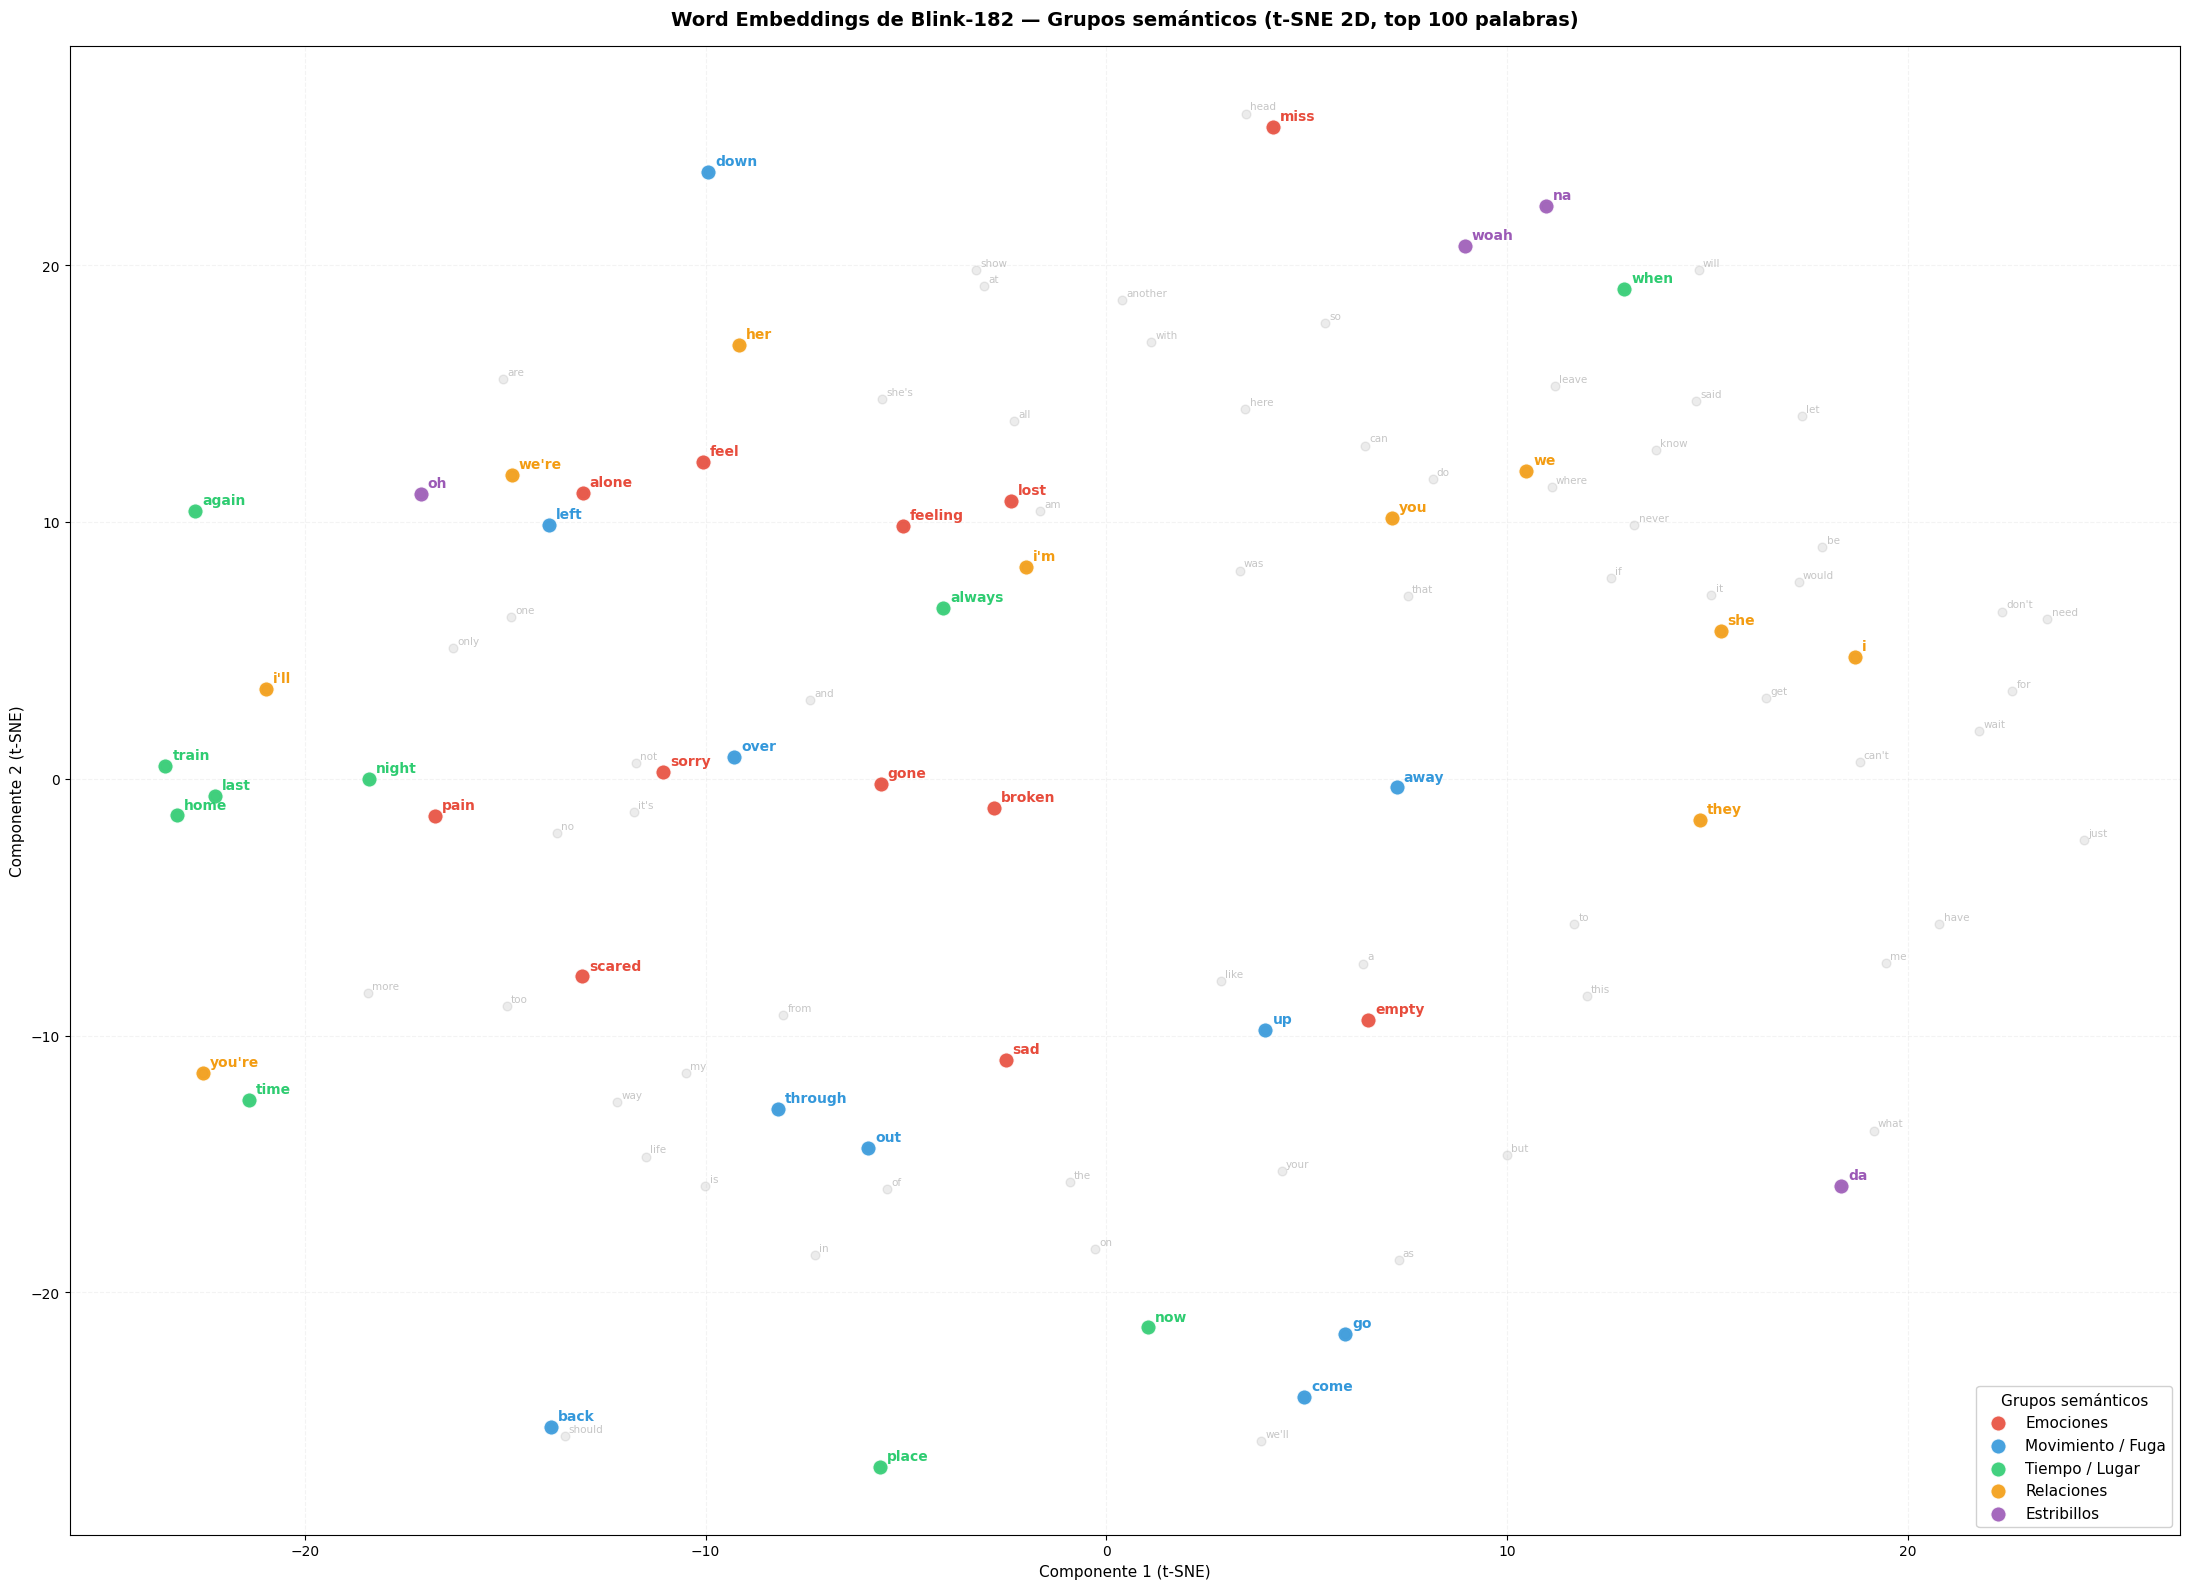

Gráfico guardado como blink182_grupos.png


In [28]:
import matplotlib.pyplot as plt
import numpy as np

# MAX_WORDS: cantidad de palabras a mostrar en el gráfico
MAX_WORDS = 100

# Definimos grupos semánticos con colores distintos
# Solo incluimos palabras que sabemos que están en el vocabulario
grupos = {
    'Emociones':          {'palabras': ['feel', 'feeling', 'alone', 'lost', 'gone', 'miss', 'sad', 'broken', 'pain', 'scared', 'sorry', 'empty'], 'color': '#e74c3c'},
    'Movimiento / Fuga':  {'palabras': ['go', 'come', 'back', 'away', 'left', 'out', 'over', 'through', 'down', 'up'], 'color': '#3498db'},
    'Tiempo / Lugar':     {'palabras': ['time', 'night', 'last', 'always', 'again', 'now', 'when', 'home', 'place', 'train'], 'color': '#2ecc71'},
    'Relaciones':         {'palabras': ['you', 'i', 'we', 'she', "i'm", "you're", "we're", "i'll", 'her', 'they'], 'color': '#f39c12'},
    'Estribillos':        {'palabras': ['na', 'da', 'oh', 'woah'], 'color': '#9b59b6'},
}

# Construimos un diccionario {palabra: (x, y)} para acceso rápido
word_to_xy = {labels[j]: (vectors_2d[j, 0], vectors_2d[j, 1]) for j in range(len(labels))}

# Palabras que pertenecen a algún grupo (para no etiquetar dos veces)
palabras_en_grupos = set()
for g in grupos.values():
    palabras_en_grupos.update(g['palabras'])

fig, ax = plt.subplots(figsize=(22, 16))

# 1. Fondo: todas las palabras del top MAX_WORDS en gris claro sin etiqueta
x_all = vectors_2d[:MAX_WORDS, 0]
y_all = vectors_2d[:MAX_WORDS, 1]
words_all = labels[:MAX_WORDS]

ax.scatter(x_all, y_all, alpha=0.15, s=40, color='gray', zorder=1)

# Etiquetas solo para palabras que NO están en ningún grupo
for j, word in enumerate(words_all):
    if word not in palabras_en_grupos:
        ax.annotate(word, xy=(x_all[j], y_all[j]),
                    xytext=(3, 3), textcoords='offset points',
                    fontsize=7.5, alpha=0.45, color='gray', zorder=2)

# 2. Encima: cada grupo con su color y etiquetas destacadas
for nombre, info in grupos.items():
    xs, ys, ws = [], [], []
    for palabra in info['palabras']:
        if palabra in word_to_xy:
            xi, yi = word_to_xy[palabra]
            xs.append(xi)
            ys.append(yi)
            ws.append(palabra)

    if xs:
        ax.scatter(xs, ys, s=120, color=info['color'], alpha=0.9,
                   label=nombre, zorder=5, edgecolors='white', linewidths=0.8)
        for xi, yi, wi in zip(xs, ys, ws):
            ax.annotate(wi, xy=(xi, yi), xytext=(5, 5),
                        textcoords='offset points',
                        fontsize=10, fontweight='bold',
                        color=info['color'], zorder=6)

ax.set_title(
    f'Word Embeddings de Blink-182 — Grupos semánticos (t-SNE 2D, top {MAX_WORDS} palabras)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Componente 1 (t-SNE)', fontsize=11)
ax.set_ylabel('Componente 2 (t-SNE)', fontsize=11)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9, title='Grupos semánticos', title_fontsize=11)
ax.grid(True, alpha=0.15, linestyle='--')

plt.tight_layout()
plt.savefig('blink182_grupos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como blink182_grupos.png')

🔴 Emociones (feel, feeling, alone, lost, gone, sorry, broken, sad, scared, empty, pain, miss)

Es el grupo más disperso del gráfico, lo que tiene sentido: las emociones en Blink-182 aparecen en contextos muy variados. Sin embargo se pueden ver dos subgrupos: uno en la zona superior-izquierda (feel, feeling, alone, lost) relacionado con estados emocionales en presente, y otro más hacia el centro-inferior (sad, broken, scared, empty) asociado a estados de derrumbe y vacío. miss quedó aislado en la parte superior derecha, lejos del resto, lo que sugiere que en el corpus aparece en contextos distintos a los demás términos emocionales.

🔵 Movimiento / Fuga (down, left, over, through, out, back, go, come, up, away)
Este grupo también está disperso a lo largo del eje vertical, lo cual es coherente: los verbos y preposiciones de movimiento en Blink-182 aparecen en contextos muy distintos dependiendo de si hablan de escapar (away, out, go) o de volver (back, come). go y come quedaron juntos en la parte inferior, cerca de now y place, formando un pequeño subgrupo de acción inmediata.

🟢 Tiempo / Lugar (again, train, home, last, night, time, when, always, place)
Este es el grupo más cohesionado del gráfico. train, home, last, night y time aparecen agrupados en la zona izquierda inferior, todos con una connotación de nostalgia y regreso. En Blink-182 estas palabras suelen aparecer juntas en letras sobre recordar el pasado ("last night", "train home", "time again"). when y always quedaron más alejados, probablemente porque funcionan más como conectores temporales que como referencias concretas.

🟡 Relaciones (i, i'm, i'll, you, you're, we, we're, her, she, they)
Los pronombres forman un grupo distribuido por el cuadrante derecho del gráfico. i, i'm, i'll están relativamente cerca entre sí (zona derecha), lo que tiene sentido: son variantes del mismo sujeto. you y we están en la zona central-derecha. Que her y she estén separados de you sugiere que en el corpus Blink-182 habla a alguien (you) en contextos distintos a cuando habla de alguien (her, she).

🟣 Estribillos (na, woah, oh, da)
na y woah están juntos en la zona superior derecha, bien separados del resto del vocabulario. Esto es exactamente lo esperado: son sílabas sin significado semántico real que aparecen exclusivamente en partes melódicas de las canciones. Que el modelo los haya ubicado lejos de todo el vocabulario con contenido confirma que aprendió correctamente que estas palabras habitan un contexto completamente distinto. da quedó aislado en el extremo derecho inferior, probablemente porque aparece en canciones específicas con un contexto propio.

El análisis del gráfico t-SNE reveló 5 grupos semánticos coherentes con el universo lírico de Blink-182:

| Grupo | Palabras clave | Compacidad | Interpretación |
|---|---|---|---|
| 🔴 Emociones | `feel`, `alone`, `broken`, `sad` | Disperso | Emociones en contextos variados |
| 🔵 Movimiento | `go`, `come`, `away`, `back` | Disperso | Tensión entre escapar y volver |
| 🟢 Tiempo / Lugar | `time`, `home`, `night`, `last` | **Compacto** | Nostalgia, contexto lírico consistente |
| 🟡 Relaciones | `you`, `i`, `we`, `she` | Moderado | Distinción interlocutor vs. personaje |
| 🟣 Estribillos | `na`, `woah`, `oh`, `da` | **Compacto** | Categoría propia sin significado semántico |

Los grupos más compactos (Tiempo/Lugar y Estribillos) son los que tienen el contexto de aparición más consistente en el corpus. Los más dispersos (Emociones y Movimiento) reflejan la riqueza y variedad con que Blink-182 trata esos temas en sus letras.